In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
df_Ml = pd.read_csv("../../data/weatherAUS_ForModel.csv") 
df_Ml = df_Ml.drop("SeasonName", axis=1)  


print("Nombre total de NaN :", df_Ml.isna().sum().sum())


Nombre total de NaN : 0


In [6]:
X = df_Ml.drop(columns=["RainTomorrow", "Date"], errors="ignore")
y = df_Ml["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,       
    max_depth=15,            
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,               
    random_state=42
)

clf = Pipeline(steps=[
    ("classifier", model)
])

In [12]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
threshold = 0.35  # plus sensible à la pluie
y_pred_custom = (y_proba >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)
recall = recall_score(y_test,y_pred_custom)

print("\n-----------Rapport de classification-----------")
print(classification_report(y_test, y_pred))
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Recall : {recall:.4f}")
print("ROC-AUC :", roc_auc_score(y_test, y_proba))


-----------Rapport de classification-----------
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     21757
           1       0.77      0.48      0.59      6262

    accuracy                           0.85     28019
   macro avg       0.82      0.72      0.75     28019
weighted avg       0.84      0.85      0.84     28019

Accuracy : 0.8440
F1-score : 0.6493
Recall : 0.6460
ROC-AUC : 0.8795397104691409


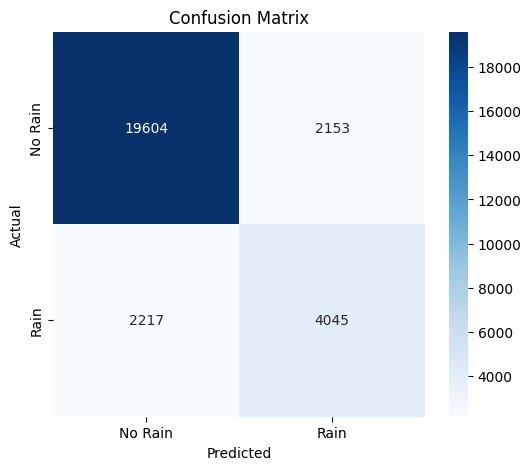

In [13]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Avec SMOTE

In [14]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("\n================ Random Forest + SMOTE ================\n")

clf_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

clf_smote.fit(X_train, y_train)

y_proba_smote = clf_smote.predict_proba(X_test)[:,1]
threshold = 0.45
y_pred_smote = (y_proba_smote >= threshold).astype(int)

print(classification_report(y_test, y_pred_smote))
print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("F1-score :", f1_score(y_test, y_pred_smote))
print("Recall :", recall_score(y_test, y_pred_smote))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_smote))


================ Random Forest + SMOTE ================

              precision    recall  f1-score   support

           0       0.91      0.86      0.89     21757
           1       0.59      0.72      0.65      6262

    accuracy                           0.83     28019
   macro avg       0.75      0.79      0.77     28019
weighted avg       0.84      0.83      0.83     28019

Accuracy : 0.8267247225097255
F1-score : 0.6486212636607078
Recall : 0.7155860747365059
ROC-AUC : 0.8814997326748674


Avec pondération des classes 


================ Random Forest (class_weight) ================

Ratio: 3.4744680001596997
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     21757
           1       0.60      0.72      0.65      6262

    accuracy                           0.83     28019
   macro avg       0.76      0.79      0.77     28019
weighted avg       0.84      0.83      0.83     28019

Accuracy : 0.8285806060173454
F1-score : 0.6531879558090837
Recall : 0.7222931970616416
ROC-AUC : 0.8832181339465308


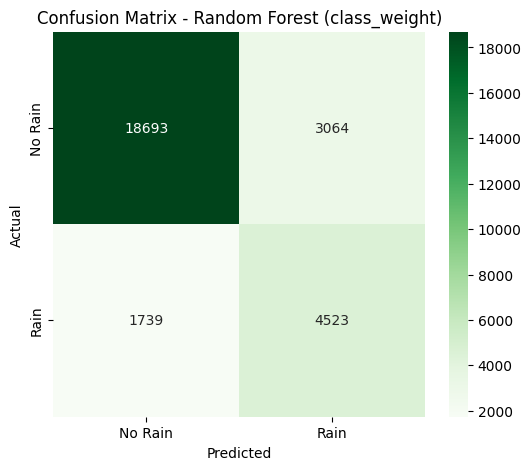

In [15]:
print("\n================ Random Forest (class_weight) ================\n")


neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

print("Ratio:", ratio)


model_weight = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight={0:1, 1:ratio},   # 🔥 ICI
    n_jobs=-1,
    random_state=42
)

model_weight.fit(X_train, y_train)


y_proba_weight = model_weight.predict_proba(X_test)[:,1]

threshold = 0.45
y_pred_weight = (y_proba_weight >= threshold).astype(int)


print(classification_report(y_test, y_pred_weight))
print("Accuracy :", accuracy_score(y_test, y_pred_weight))
print("F1-score :", f1_score(y_test, y_pred_weight))
print("Recall :", recall_score(y_test, y_pred_weight))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_weight))


cm_weight = confusion_matrix(y_test, y_pred_weight)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_weight,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - Random Forest (class_weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
print("\n================ TABLEAU COMPARATIF RANDOM FOREST ================\n")

results_rf = []

threshold = 0.45  


# RF NORMAL

y_proba_rf = clf.predict_proba(X_test)[:,1]
y_pred_rf = (y_proba_rf >= threshold).astype(int)

results_rf.append({
    "Model": "RF Normal",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
})



# RF + SMOTE

y_proba_smote = clf_smote.predict_proba(X_test)[:,1]
y_pred_smote = (y_proba_smote >= threshold).astype(int)

results_rf.append({
    "Model": "RF + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "F1": f1_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "ROC-AUC": roc_auc_score(y_test, y_proba_smote)
})



#RF + class_weight

y_proba_weight = model_weight.predict_proba(X_test)[:,1]
y_pred_weight = (y_proba_weight >= threshold).astype(int)

results_rf.append({
    "Model": "RF + class_weight",
    "Accuracy": accuracy_score(y_test, y_pred_weight),
    "F1": f1_score(y_test, y_pred_weight),
    "Recall": recall_score(y_test, y_pred_weight),
    "ROC-AUC": roc_auc_score(y_test, y_proba_weight)
})


df_rf = pd.DataFrame(results_rf)
print(df_rf)


================ TABLEAU COMPARATIF RANDOM FOREST ================

               Model  Accuracy        F1    Recall   ROC-AUC
0          RF Normal  0.851743  0.617002  0.534334  0.879540
1         RF + SMOTE  0.826725  0.648621  0.715586  0.881500
2  RF + class_weight  0.828581  0.653188  0.722293  0.883218
